In [94]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

C1 = '#f5f4b3' #'#3DB2FF' #'#FFAF45'
C2 = '#898121' #'salmon'  #'#FB6D48'
C3 = '#1f4529'#'green'   #'#D74B76'
C4 = '#abba7c'#'#673F69' #'#673F69'
C5 = '#FFAF45'
C6 = '#bccbf1'

In [136]:
def read_csv_file(filename: str) -> dict:
    d = {}
    with open(filename, 'r') as rd:
        lines= rd.readlines()
        
    header = lines[0]
    header = header.strip().split(',')[1:]
    for line in lines[1:]:
        x = line.strip().split(',')
        if len(x) == 1:
            continue
        workload = x[0]
        for i in range(len(header)):
            if workload not in d:
                d[workload] = {}
            d[workload][header[i]] = float(x[i+1])
    return d

EXCLUDE = ['bc', 'cc', 'sssp', 'tc', 'bfs', 'pr']

def get_stats_for_builds(builds: list[str], stat_name: str, reference_mpki: dict, mpki_min=1.5) -> dict:
    out = {}
    
    for b in builds:
        d = read_csv_file(f'{b}.csv')
        out[b] = { w: stats[stat_name] for (w,stats) in d.items() if reference_mpki[w] >= mpki_min }
    return out

In [137]:
baseline_stats = read_csv_file('baseline_core8_lru.csv')
reference_mpki = { w: stats['llc_mpki'] for (w,stats) in baseline_stats.items() }
print(reference_mpki)

{'povray': 0.0247, 'mcf': 18.97476969043074, 'namd': 0.22900000000000004, 'fotonik3d': 26.6, 'cam4': 3.7400000000000007, 'deepsjeng': 0.278, 'imagick': 0.1284941630706176, 'wrf': 0.257, 'parest': 26.512176637174687, 'leela': 0.0261, 'lbm': 27.699999999999996, 'nab': 0.6054995871180843, 'blender': 1.07, 'cactuBSSN': 3.5299999999999994, 'perlbench': 0.08814997163925128, 'x264': 0.26437222569850166, 'xz': 5.148718646883512, 'gcc': 0.46337287546832506, 'roms': 7.854987263158209, 'xalancbmk': 1.5874881516587678, 'omnetpp': 9.174997275204358, 'bwaves': 41.9, 'cc': 86.0, 'bc': 7.897497624326892, 'sssp': 2.408745445080687, 'tc': 41.00000000000001, 'pr': 22.7, 'bfs': 17.0}


In [148]:
# SOL stats:
tCCD_S_WR = 8

def compute_sol_speedup(build: str):
    stats = read_csv_file(f'{build}.csv')
    out = []
    for w in stats:
        tot_cycles = stats[w]['dram_cycles']
        write_cycles = stats[w]['write_cycles']
        ideal_write_cycles = stats[w]['num_writes'] * tCCD_S_WR

        if write_cycles == 0:
            continue
        
        ideal_cycles = tot_cycles - write_cycles + ideal_write_cycles
        out.append(tot_cycles/ideal_cycles)
    out.append(sp.stats.gmean(out))

    return out[-1]

print('SOL speedup:', compute_sol_speedup('baseline_core8_lru'))

SOL speedup: 1.1052571750338318


In [138]:
def plot_relative_stat(output_file, builds: list[str], stat_name: str, y_label: str, labels: list, color_list: list, negate=False, percentage=False, plot_best_of_all=False):
    stats = get_stats_for_builds(builds, stat_name, reference_mpki=reference_mpki)

    n_labels = len(builds)
    if plot_best_of_all:
        n_labels += 1
    
    fig, ax = plt.subplots()
    fig.set_size_inches(12.0, 3.4)

    # Plot stats for each build:
    baseline_ipc_list = stats[builds[0]]
    width = 1.0 / n_labels
    off = 0

    gmean_list = []

    best_of_all = [-100 for _ in baseline_ipc_list]
    
    for (i, (b, ipc_list)) in enumerate(stats.items()):
        if i == 0:
            continue
        X = np.arange(len(ipc_list)+1)
        
        Y = [ ipc_list[w]/baseline_ipc_list[w] for w in ipc_list ]

        best_of_all = [max(best_of_all[i], Y[i]) for i in range(len(Y))]
        
        Y.append(sp.stats.gmean(Y))
        Y = np.array(Y)
        if percentage:
            Y = (Y-1) * 100
        if negate:
            Y = -Y
            
        gmean_list.append(Y[-1])
        ax.bar(X+off, Y, width, color=color_list[i-1], label=labels[i-1], zorder=3, edgecolor='k')
        off += width

    if plot_best_of_all:
        best_of_all.append(sp.stats.gmean(best_of_all))
        best_of_all = np.array(best_of_all)
        if percentage:
            best_of_all = (best_of_all-1) * 100
        if negate:
            best_of_all = best_of_all

        gmean_list.append(best_of_all[-1])
        ax.bar(X+off, best_of_all, width, color=C6, label='BoA', zorder=3, edgecolor='k')
    
    # Setup anything else that is remaining:
    workloads = [w for w in baseline_ipc_list]
    workloads.append('gmean')
    
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xticks(X + (len(builds)-1)/2 * width, workloads, rotation=30, ha='right', fontsize=12)
    ax.grid(visible=True, axis='y', zorder=0)
    ax.set_ylim(bottom=-7.5)
    
    ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=n_labels, loc='upper center')
    plt.tight_layout()
    plt.savefig(output_file, bbox_inches='tight')

    # Print out gmeans:
    for (i,b) in enumerate(builds[1:]):
        g = gmean_list[i]
        print(f'{stat_name} GMEAN of {b}\t{g:.3f}')

    if plot_best_of_all:
        print(f'{stat_name} GMEAN of BoA\t{gmean_list[-1]:.3f}')
    print('----------------------------')

ipc GMEAN of ddr3_core8_lru_close_noturn	0.112
ipc GMEAN of ddr3_core8_lru_open	10.530
ipc GMEAN of ddr3_core8_lru_open_noturn	10.807
ipc GMEAN of ddr3_core8_lru_hybrid	10.634
ipc GMEAN of ddr3_core8_lru_hybrid_noturn	10.586
----------------------------
ipc GMEAN of ddr5_core8_lru_close_noturn	1.123
ipc GMEAN of ddr5_core8_lru_open	0.249
ipc GMEAN of ddr5_core8_lru_open_noturn	1.386
ipc GMEAN of ddr5_core8_lru_hybrid	2.612
ipc GMEAN of ddr5_core8_lru_hybrid_noturn	4.281
----------------------------


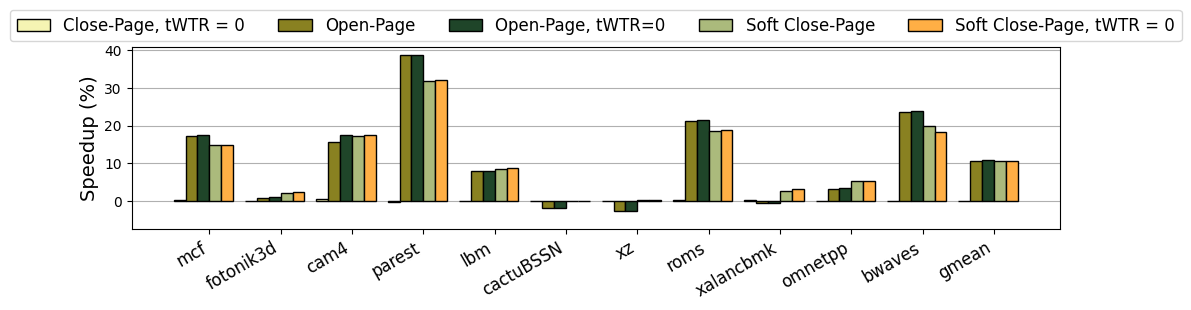

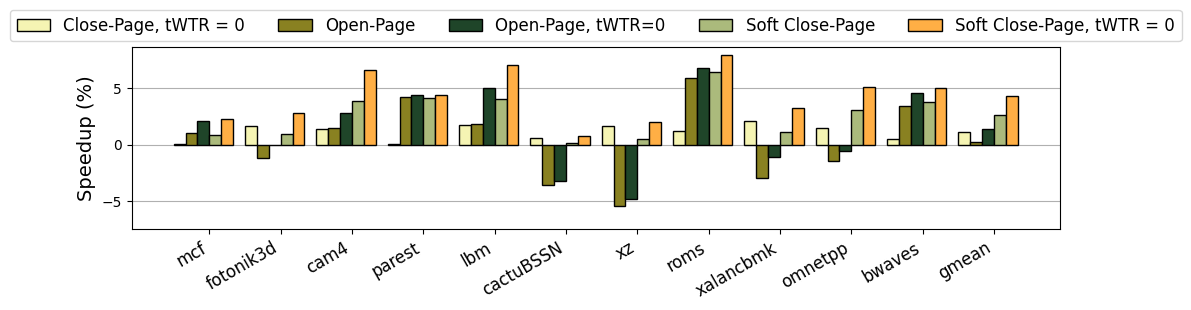

In [139]:
plot_relative_stat('plots/ddr3_results.pdf',
                   ['ddr3_core8_lru_close', 'ddr3_core8_lru_close_noturn', 'ddr3_core8_lru_open', 'ddr3_core8_lru_open_noturn', 'ddr3_core8_lru_hybrid', 'ddr3_core8_lru_hybrid_noturn'],
                   'ipc',
                   'Speedup (%)',
                   ['Close-Page, tWTR = 0', 'Open-Page', 'Open-Page, tWTR=0', 'Soft Close-Page', 'Soft Close-Page, tWTR = 0'],
                   [C1, C2, C3, C4, C5],
                   percentage=True)

plot_relative_stat('plots/ddr5_results.pdf',
                   ['ddr5_core8_lru_close', 'ddr5_core8_lru_close_noturn', 'ddr5_core8_lru_open', 'ddr5_core8_lru_open_noturn', 'ddr5_core8_lru_hybrid', 'ddr5_core8_lru_hybrid_noturn'],
                   'ipc',
                   'Speedup (%)',
                   ['Close-Page, tWTR = 0', 'Open-Page', 'Open-Page, tWTR=0', 'Soft Close-Page', 'Soft Close-Page, tWTR = 0'],
                   [C1, C2, C3, C4, C5],
                   percentage=True)

ipc GMEAN of vwq_core8_lru	-0.419
ipc GMEAN of wcache_core8_lru	1.435
ipc GMEAN of BoA	2.925
----------------------------
ipc GMEAN of wcache_core8_srrip	1.589
----------------------------


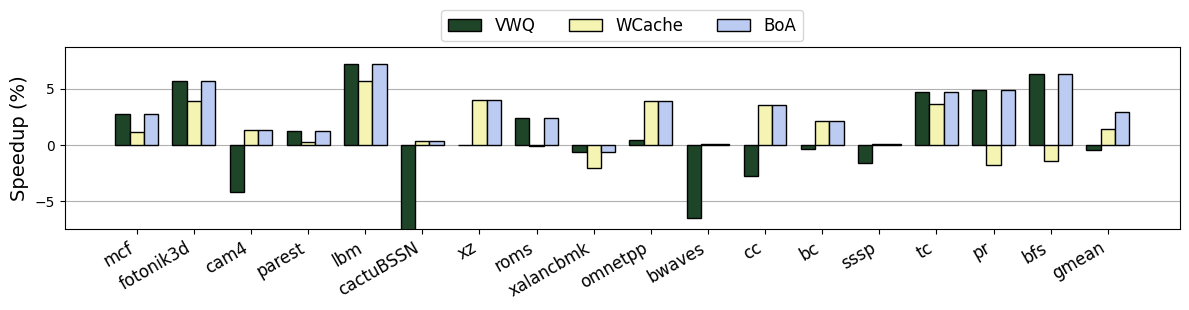

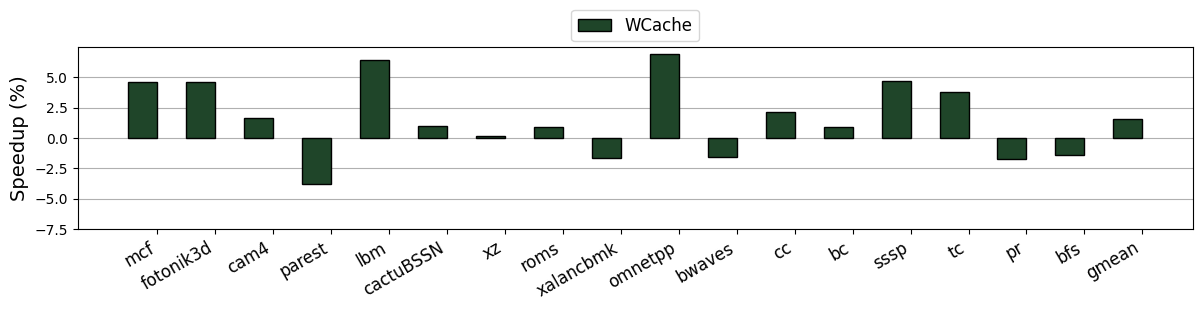

In [140]:
# Main evaluations:
plot_relative_stat('plots/main_evals_lru.pdf',
                   ['baseline_core8_lru', 'vwq_core8_lru', 'wcache_core8_lru'],
                   'ipc',
                   'Speedup (%)',
                   ['VWQ', 'WCache'],
                   [C3, C1],
                   percentage=True, plot_best_of_all=True)
plot_relative_stat('plots/main_evals_srrip.pdf',
                   ['baseline_core8_srrip', 'wcache_core8_srrip'],
                   'ipc',
                   'Speedup (%)',
                   ['WCache'],
                   [C3],
                   percentage=True)

ipc GMEAN of wcache_sens_lookup_2	0.662
ipc GMEAN of wcache_sens_lookup_4	1.311
ipc GMEAN of wcache_sens_lookup_8	1.067
ipc GMEAN of wcache_sens_lookup_12	-0.094
ipc GMEAN of wcache_sens_lookup_16	-2.310
ipc GMEAN of BoA	1.749
----------------------------
ipc GMEAN of wcache_sens_sampling_8	1.348
ipc GMEAN of wcache_sens_sampling_16	1.342
ipc GMEAN of wcache_sens_sampling_32	1.435
ipc GMEAN of wcache_sens_sampling_64	1.512
ipc GMEAN of wcache_sens_sampling_128	1.429
----------------------------


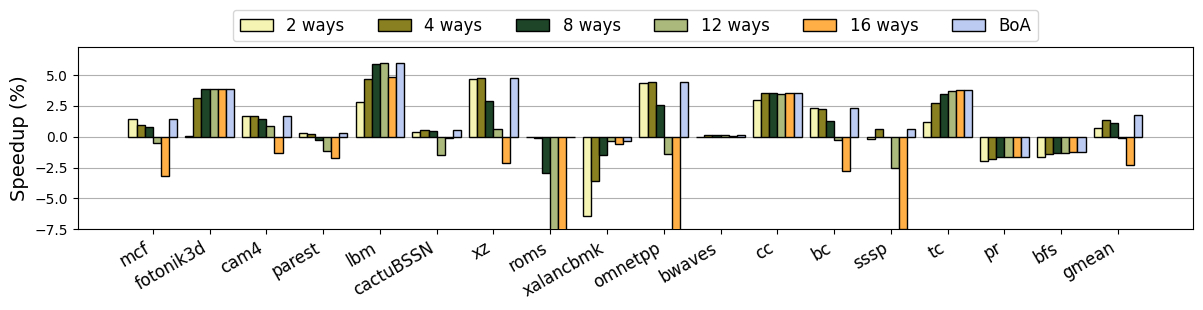

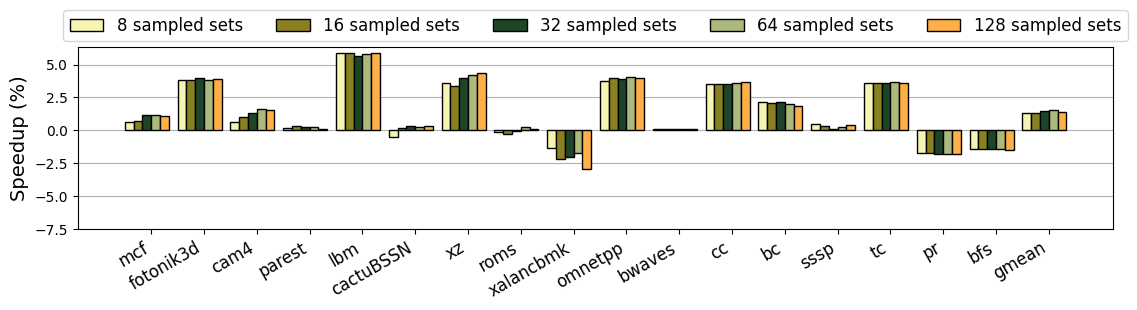

In [141]:
# Sensitivity results:
plot_relative_stat('plots/wcache_lookup_sens.pdf',
                   ['baseline_core8_lru', 'wcache_sens_lookup_2', 'wcache_sens_lookup_4', 'wcache_sens_lookup_8', 'wcache_sens_lookup_12', 'wcache_sens_lookup_16'],
                   'ipc',
                   'Speedup (%)',
                   ['2 ways', '4 ways', '8 ways', '12 ways', '16 ways'],
                   [C1,C2,C3,C4,C5],
                   percentage=True, plot_best_of_all=True)

plot_relative_stat('plots/wcache_sampling_sens.pdf',
                   ['baseline_core8_lru', 'wcache_sens_sampling_8', 'wcache_sens_sampling_16', 'wcache_sens_sampling_32', 'wcache_sens_sampling_64', 'wcache_sens_sampling_128'],
                   'ipc',
                   'Speedup (%)',
                   ['8 sampled sets', '16 sampled sets', '32 sampled sets', '64 sampled sets', '128 sampled sets'],
                   [C1,C2,C3,C4,C5],
                   percentage=True)